# Tutorial 02: Baseline Correction Guide
## EPR Baseline Correction with EPyR Tools

This tutorial demonstrates baseline correction techniques for EPR spectroscopy data using EPyR Tools. We will cover:

### Learning Objectives

- Understanding baseline artifacts in EPR data
- Adding artificial baseline drift to simulate real-world scenarios
- Applying polynomial baseline correction to 1D CW EPR spectra
- Correcting baseline drift in 2D time-domain EPR data
- Evaluating correction quality

### What are Baseline Artifacts?

EPR baselines can be distorted by several factors:
- **Instrumental drift**: Temperature and electronics variations
- **Sample effects**: Dielectric loading, background absorption
- **Cavity effects**: Resonance frequency changes
- **Phase errors**: Improper quadrature detection settings

Let's start by loading the necessary libraries and setting up our environment.

## Setup and Imports

In [3]:
# Essential imports
import epyr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configure matplotlib for better visualization
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 1.5

print(f"EPyR Tools Version: {epyr.__version__}")
print(f"Baseline module available: {hasattr(epyr, 'baseline')}")

# Set up data path
data_path = Path('../data')
print(f"Data directory exists: {data_path.exists()}")

EPyR Tools Version: 0.2.0
Baseline module available: True
Data directory exists: True


## Part 1: 1D Baseline Correction with Artificial Drift

We will load a clean CW EPR spectrum, artificially add baseline drift to simulate real experimental conditions, and then correct it using polynomial baseline correction.

### Step 1: Load Clean EPR Data

Loading 1D EPR data: 130406SB_CaWO4_Er_CW_5K_20.DSC


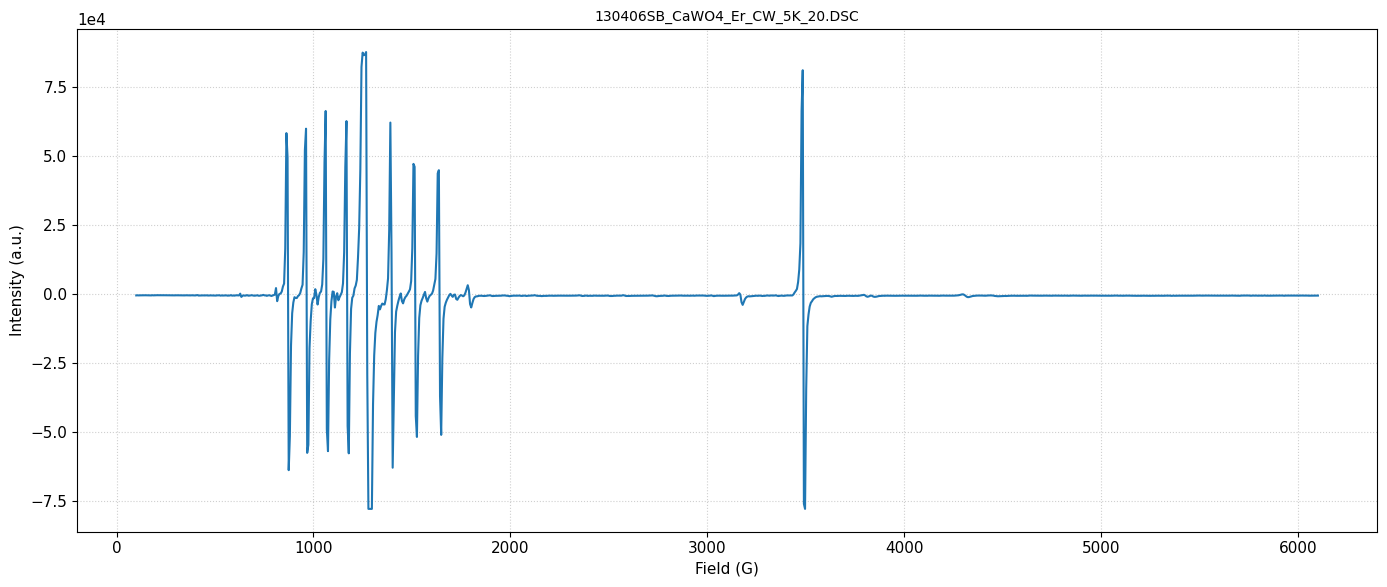


Data loaded successfully:
Field range: 100.0 to 6100.0 G
Data points: 1024
Signal range: -7.79e+04 to 8.75e+04


In [4]:
# Load the Er3+ in CaWO4 CW EPR spectrum
filename_1d = data_path / '130406SB_CaWO4_Er_CW_5K_20.DSC'

print(f"Loading 1D EPR data: {filename_1d.name}")
field, intensity, params, filepath = epyr.eprload(str(filename_1d))

print(f"\nData loaded successfully:")
print(f"Field range: {field.min():.1f} to {field.max():.1f} G")
print(f"Data points: {len(field)}")
print(f"Signal range: {intensity.min():.2e} to {intensity.max():.2e}")

# Store the original clean data
intensity_clean = intensity.copy()

### Step 2: Add Artificial Baseline Drift

We will add different types of baseline drift to demonstrate various correction scenarios:
- Linear drift (simulating gradual instrumental drift)
- Quadratic drift (simulating more complex baseline curvature)
- Cubic drift (simulating severe baseline distortion)

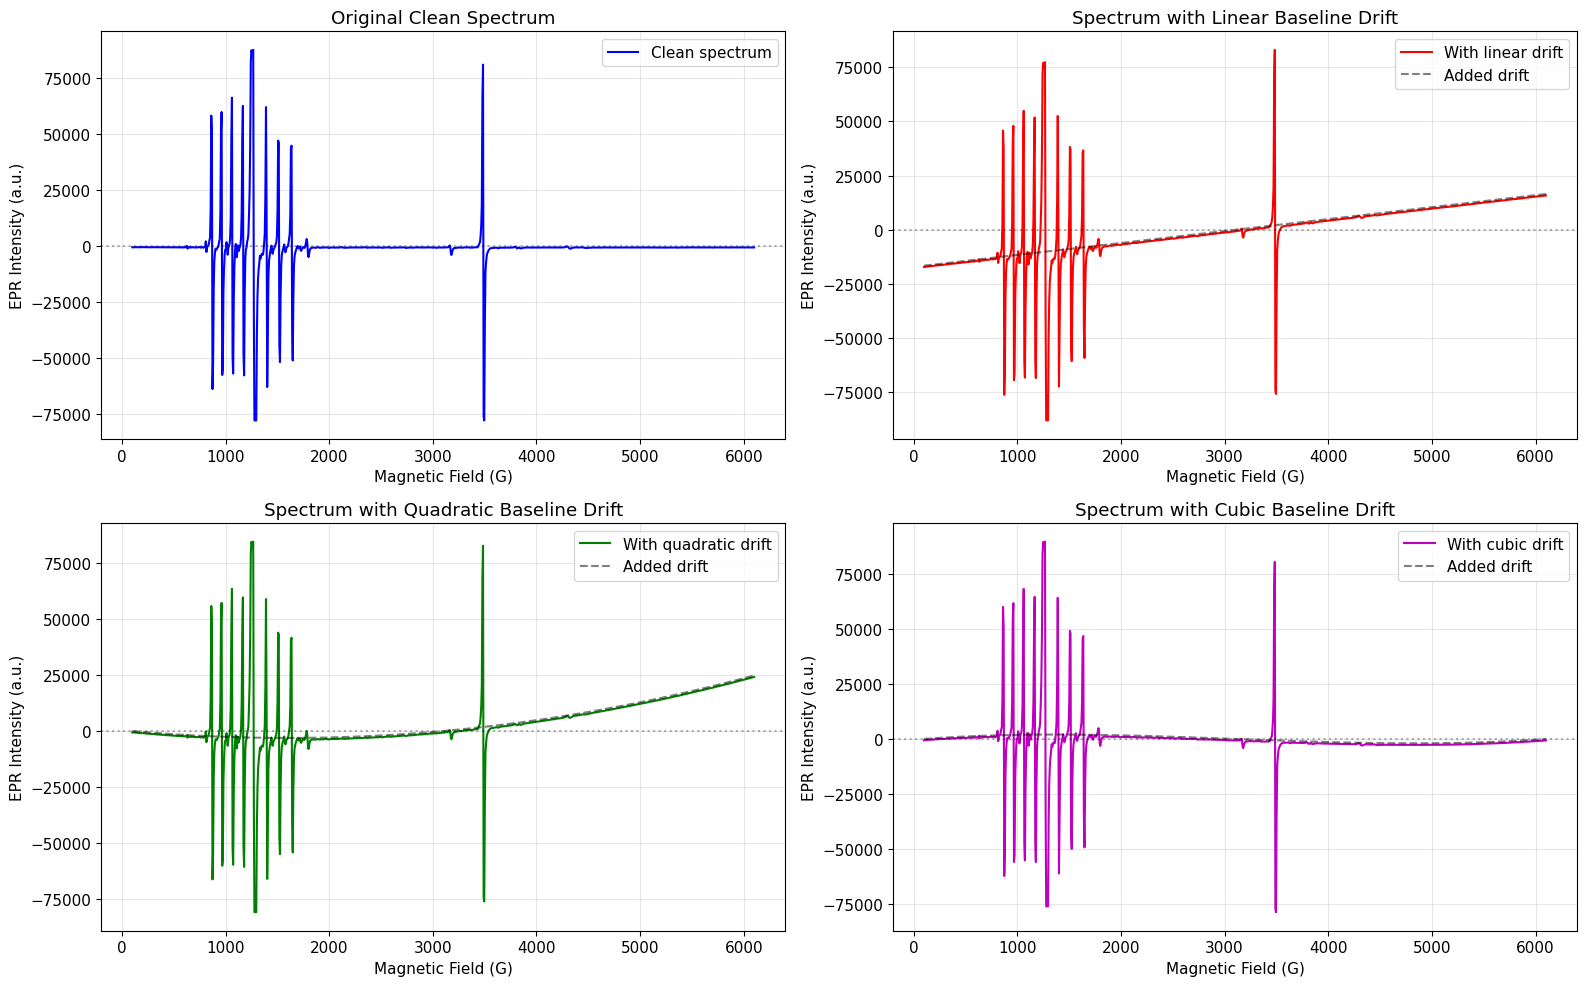


Artificial baseline drifts added successfully.


In [5]:
# Normalize field axis to [0, 1] for polynomial generation
field_norm = (field - field.min()) / (field.max() - field.min())

# Generate different baseline drifts
# Scale factors are chosen to create visible but realistic drift
signal_amplitude = intensity_clean.max() - intensity_clean.min()

# Linear drift: 20% of signal amplitude
drift_linear = 0.2 * signal_amplitude * (field_norm - 0.5)

# Quadratic drift: creates a gentle curve
drift_quadratic = 0.3 * signal_amplitude * (field_norm**2 - 0.5 * field_norm)

# Cubic drift: creates more complex baseline
drift_cubic = 0.25 * signal_amplitude * (field_norm**3 - 1.5 * field_norm**2 + 0.5 * field_norm)

# Add drift to clean signal
intensity_linear = intensity_clean + drift_linear
intensity_quadratic = intensity_clean + drift_quadratic
intensity_cubic = intensity_clean + drift_cubic

# Visualize the original and drifted data
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original clean data
axes[0, 0].plot(field, intensity_clean, 'b-', label='Clean spectrum')
axes[0, 0].axhline(y=0, color='k', linestyle=':', alpha=0.3)
axes[0, 0].set_xlabel('Magnetic Field (G)')
axes[0, 0].set_ylabel('EPR Intensity (a.u.)')
axes[0, 0].set_title('Original Clean Spectrum')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Linear drift
axes[0, 1].plot(field, intensity_linear, 'r-', label='With linear drift')
axes[0, 1].plot(field, drift_linear, 'k--', alpha=0.5, label='Added drift')
axes[0, 1].axhline(y=0, color='k', linestyle=':', alpha=0.3)
axes[0, 1].set_xlabel('Magnetic Field (G)')
axes[0, 1].set_ylabel('EPR Intensity (a.u.)')
axes[0, 1].set_title('Spectrum with Linear Baseline Drift')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Quadratic drift
axes[1, 0].plot(field, intensity_quadratic, 'g-', label='With quadratic drift')
axes[1, 0].plot(field, drift_quadratic, 'k--', alpha=0.5, label='Added drift')
axes[1, 0].axhline(y=0, color='k', linestyle=':', alpha=0.3)
axes[1, 0].set_xlabel('Magnetic Field (G)')
axes[1, 0].set_ylabel('EPR Intensity (a.u.)')
axes[1, 0].set_title('Spectrum with Quadratic Baseline Drift')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Cubic drift
axes[1, 1].plot(field, intensity_cubic, 'm-', label='With cubic drift')
axes[1, 1].plot(field, drift_cubic, 'k--', alpha=0.5, label='Added drift')
axes[1, 1].axhline(y=0, color='k', linestyle=':', alpha=0.3)
axes[1, 1].set_xlabel('Magnetic Field (G)')
axes[1, 1].set_ylabel('EPR Intensity (a.u.)')
axes[1, 1].set_title('Spectrum with Cubic Baseline Drift')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nArtificial baseline drifts added successfully.")

### Step 3: Apply Polynomial Baseline Correction

Now we will correct each drifted spectrum using polynomial baseline correction with appropriate polynomial orders.

Testing baseline correction with different polynomial orders...

Processing Linear drift...
  Order 1: Baseline std = 7.99e+01, Residual = 5.46e+01
  Order 2: Baseline std = 8.60e+01, Residual = 1.40e+02
  Order 3: Baseline std = 1.26e+02, Residual = 1.46e+02

Processing Quadratic drift...
  Order 1: Baseline std = 1.30e+03, Residual = 3.71e+03
  Order 2: Baseline std = 8.60e+01, Residual = 1.40e+02
  Order 3: Baseline std = 1.26e+02, Residual = 1.46e+02

Processing Cubic drift...
  Order 1: Baseline std = 1.14e+03, Residual = 7.84e+02
  Order 2: Baseline std = 1.14e+03, Residual = 7.95e+02
  Order 3: Baseline std = 1.26e+02, Residual = 1.46e+02



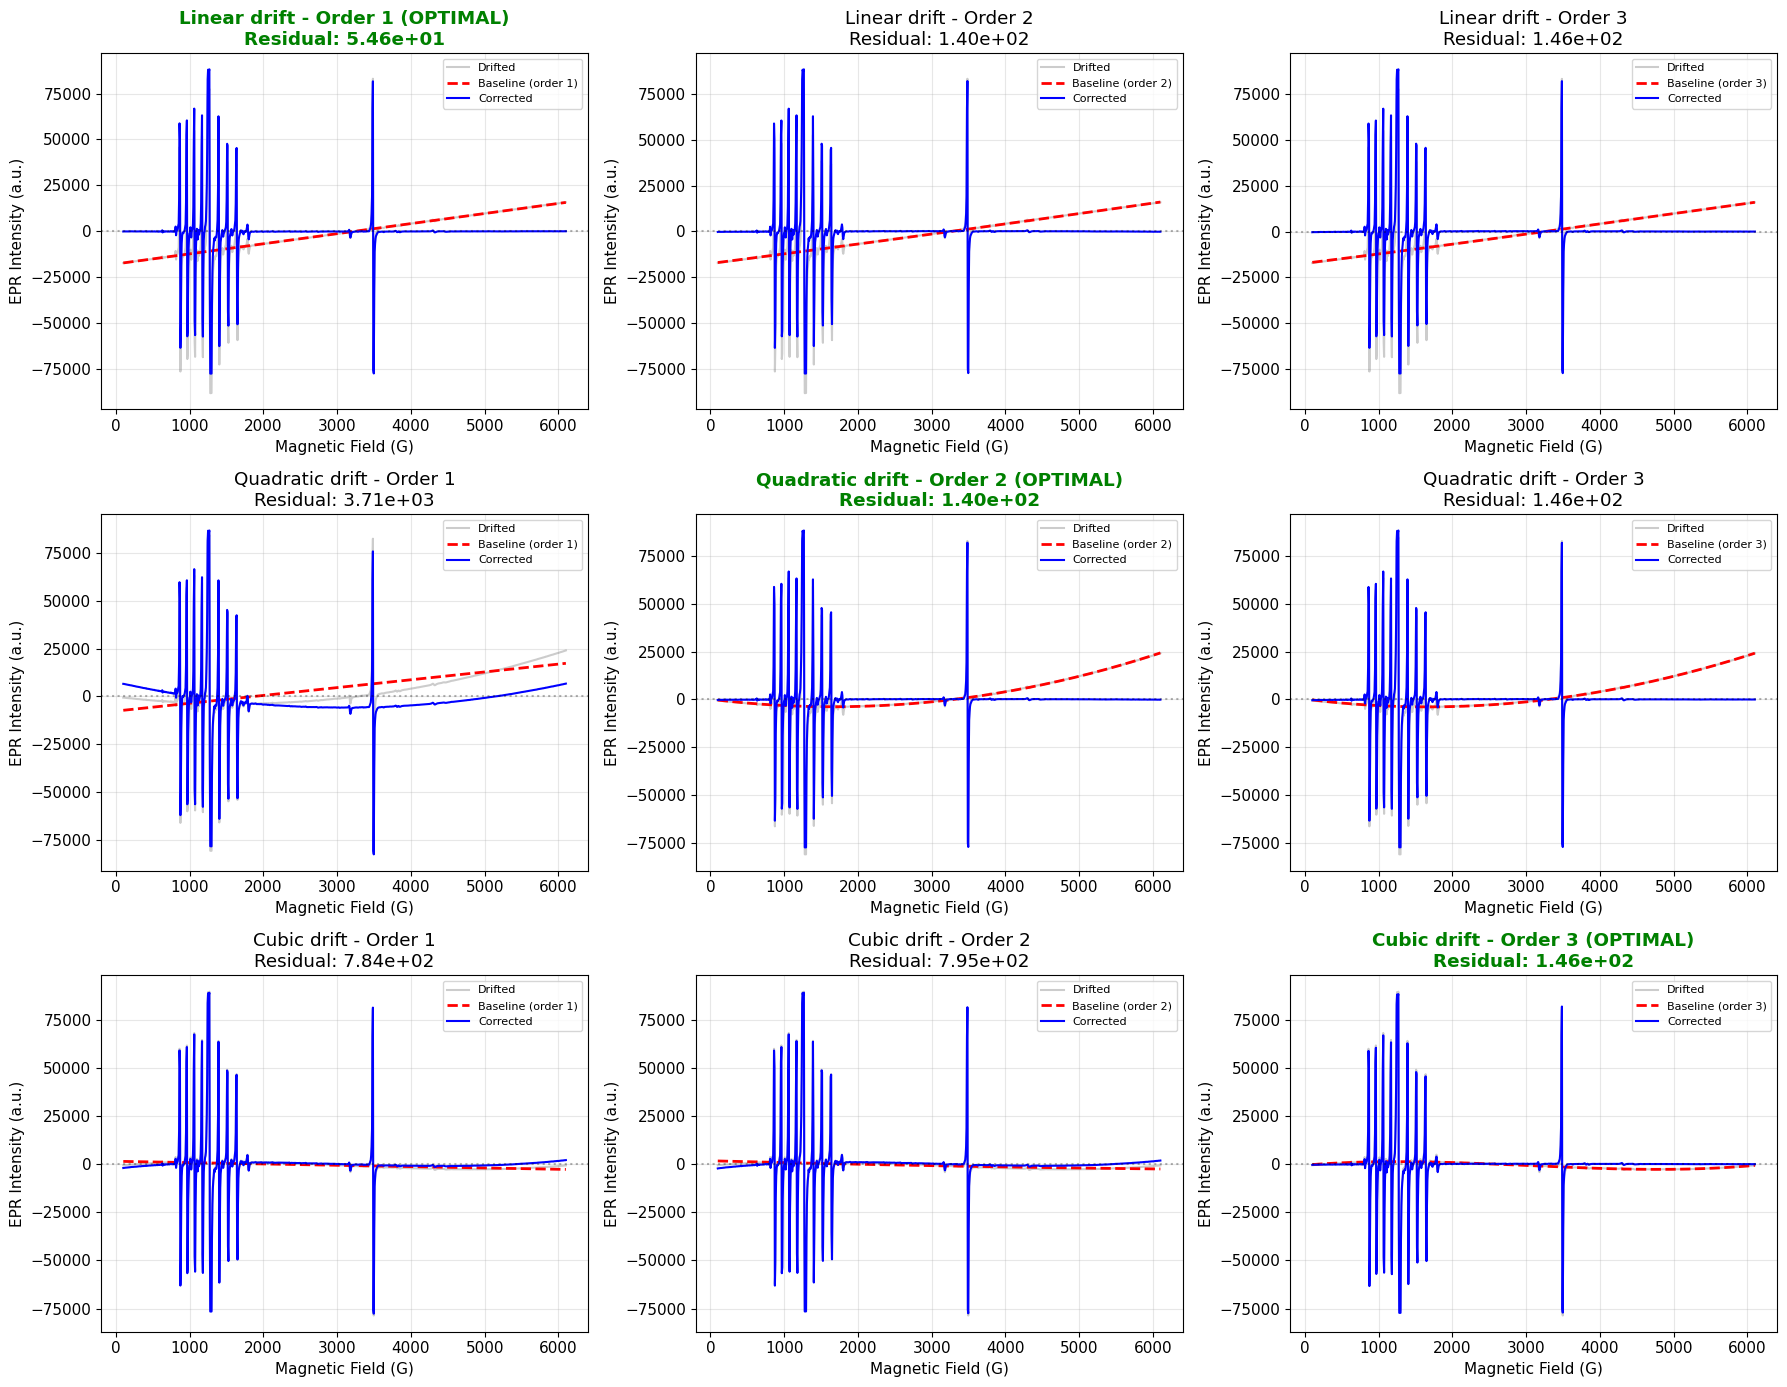


1D baseline correction demonstration complete.

Key findings:
- Linear drift is best corrected with polynomial order 1
- Quadratic drift requires polynomial order 2
- Cubic drift needs polynomial order 3
- Higher order polynomials can correct lower order drifts, but may introduce artifacts


In [6]:
# Test different polynomial orders for each drift type
print("Testing baseline correction with different polynomial orders...\n")

# Prepare data for correction
test_cases = [
    ('Linear drift', intensity_linear, 1),
    ('Quadratic drift', intensity_quadratic, 2),
    ('Cubic drift', intensity_cubic, 3)
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for row, (drift_name, intensity_drifted, optimal_order) in enumerate(test_cases):
    print(f"Processing {drift_name}...")
    
    # Test multiple polynomial orders
    for col, order in enumerate([1, 2, 3]):
        try:
            # Apply baseline correction
            corrected, baseline = epyr.baseline.baseline_polynomial_1d(
                field, intensity_drifted, params,
                order=order
            )
            
            # Calculate correction quality
            # Use edge regions for baseline noise estimation
            edge_points = len(field) // 10
            baseline_region = np.concatenate([
                corrected[:edge_points],
                corrected[-edge_points:]
            ])
            baseline_std = np.std(baseline_region)
            
            # Calculate residual compared to original clean data
            residual = np.std(corrected - intensity_clean)
            
            # Plot
            ax = axes[row, col]
            ax.plot(field, intensity_drifted, 'gray', alpha=0.4, label='Drifted')
            ax.plot(field, baseline, 'r--', linewidth=2, label=f'Baseline (order {order})')
            ax.plot(field, corrected, 'b-', label='Corrected')
            
            if order == optimal_order:
                ax.set_title(f'{drift_name} - Order {order} (OPTIMAL)\nResidual: {residual:.2e}',
                           fontweight='bold', color='green')
            else:
                ax.set_title(f'{drift_name} - Order {order}\nResidual: {residual:.2e}')
            
            ax.set_xlabel('Magnetic Field (G)')
            ax.set_ylabel('EPR Intensity (a.u.)')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)
            ax.axhline(y=0, color='k', linestyle=':', alpha=0.3)
            
            print(f"  Order {order}: Baseline std = {baseline_std:.2e}, Residual = {residual:.2e}")
            
        except Exception as e:
            print(f"  Order {order}: Failed - {e}")
            axes[row, col].text(0.5, 0.5, f'Error with order {order}',
                              transform=axes[row, col].transAxes,
                              ha='center', va='center',
                              bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
    
    print()

plt.tight_layout()
plt.show()

print("\n1D baseline correction demonstration complete.")
print("\nKey findings:")
print("- Linear drift is best corrected with polynomial order 1")
print("- Quadratic drift requires polynomial order 2")
print("- Cubic drift needs polynomial order 3")
print("- Higher order polynomials can correct lower order drifts, but may introduce artifacts")

### Step 4: Comparison with Original Clean Data

Let's compare the corrected spectra with the original clean data to assess correction quality.

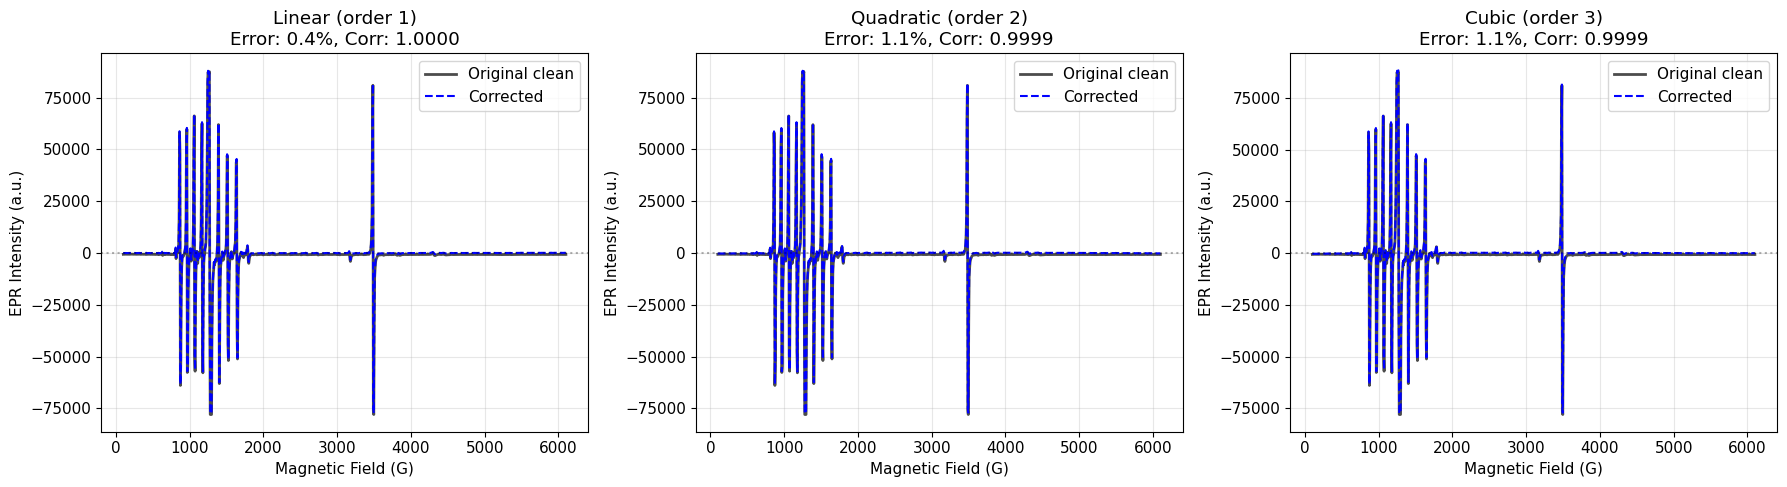


Correction quality assessment:
Linear (order 1):
  - Recovery error: 0.42%
  - Correlation with original: 1.0000
Quadratic (order 2):
  - Recovery error: 1.07%
  - Correlation with original: 0.9999
Cubic (order 3):
  - Recovery error: 1.12%
  - Correlation with original: 0.9999


In [7]:
# Apply optimal corrections
corrected_linear, baseline_linear = epyr.baseline.baseline_polynomial_1d(
    field, intensity_linear, params, order=1
)
corrected_quadratic, baseline_quadratic = epyr.baseline.baseline_polynomial_1d(
    field, intensity_quadratic, params, order=2
)
corrected_cubic, baseline_cubic = epyr.baseline.baseline_polynomial_1d(
    field, intensity_cubic, params, order=3
)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

corrections = [
    ('Linear (order 1)', corrected_linear),
    ('Quadratic (order 2)', corrected_quadratic),
    ('Cubic (order 3)', corrected_cubic)
]

for ax, (title, corrected) in zip(axes, corrections):
    ax.plot(field, intensity_clean, 'k-', alpha=0.7, linewidth=2, label='Original clean')
    ax.plot(field, corrected, 'b--', linewidth=1.5, label='Corrected')
    
    # Calculate and display recovery quality
    recovery_error = np.std(corrected - intensity_clean) / np.std(intensity_clean) * 100
    correlation = np.corrcoef(corrected, intensity_clean)[0, 1]
    
    ax.set_xlabel('Magnetic Field (G)')
    ax.set_ylabel('EPR Intensity (a.u.)')
    ax.set_title(f'{title}\nError: {recovery_error:.1f}%, Corr: {correlation:.4f}')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.axhline(y=0, color='k', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCorrection quality assessment:")
for title, corrected in corrections:
    recovery_error = np.std(corrected - intensity_clean) / np.std(intensity_clean) * 100
    correlation = np.corrcoef(corrected, intensity_clean)[0, 1]
    print(f"{title}:")
    print(f"  - Recovery error: {recovery_error:.2f}%")
    print(f"  - Correlation with original: {correlation:.4f}")

## Part 2: 2D Baseline Correction

Now we will work with 2D time-domain EPR data (Rabi oscillations). 2D data often requires row-by-row or slice-by-slice baseline correction.

### Step 1: Load 2D EPR Data

Loading 2D EPR data: Rabi2D_GdCaWO4_6dB_3770G_2.DSC
Plotting 2D data (real part) using pcolormesh.


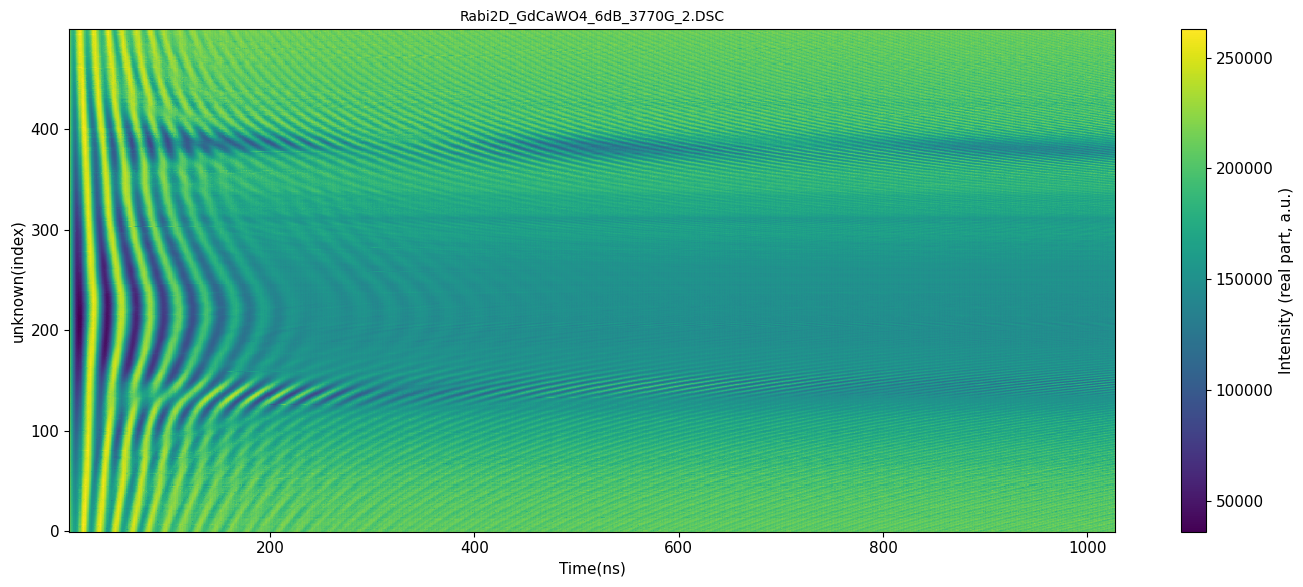


2D Data loaded successfully:
Data shape: (500, 1024)
Data type: <class 'list'>
Time points: 1024
Field/trace points: 500
Time range: 4.00 to 1027.00 ns


In [11]:
# Load 2D Rabi oscillation data
filename_2d = data_path / 'Rabi2D_GdCaWO4_6dB_3770G_2.DSC'

print(f"Loading 2D EPR data: {filename_2d.name}")
x_2d, y_2dc, params_2d, filepath_2d = epyr.eprload(str(filename_2d))
y_2d=np.real(y_2dc)
print(f"\n2D Data loaded successfully:")
print(f"Data shape: {y_2d.shape}")
print(f"Data type: {type(x_2d)}")

# Handle both 1D and 2D x-axis formats
if isinstance(x_2d, tuple) or isinstance(x_2d, list):
    time_axis = x_2d[0]  # Time axis
    field_axis_2d = x_2d[1]  # Field or secondary axis
    print(f"Time points: {len(time_axis)}")
    print(f"Field/trace points: {len(field_axis_2d)}")
    print(f"Time range: {time_axis[0]:.2f} to {time_axis[-1]:.2f} ns")
else:
    # Single axis case
    time_axis = x_2d
    field_axis_2d = np.arange(y_2d.shape[0])
    print(f"Time points: {len(time_axis)}")
    print(f"Traces: {len(field_axis_2d)}")

### Step 2: Visualize Raw 2D Data

Let's visualize the raw 2D data to identify baseline issues.

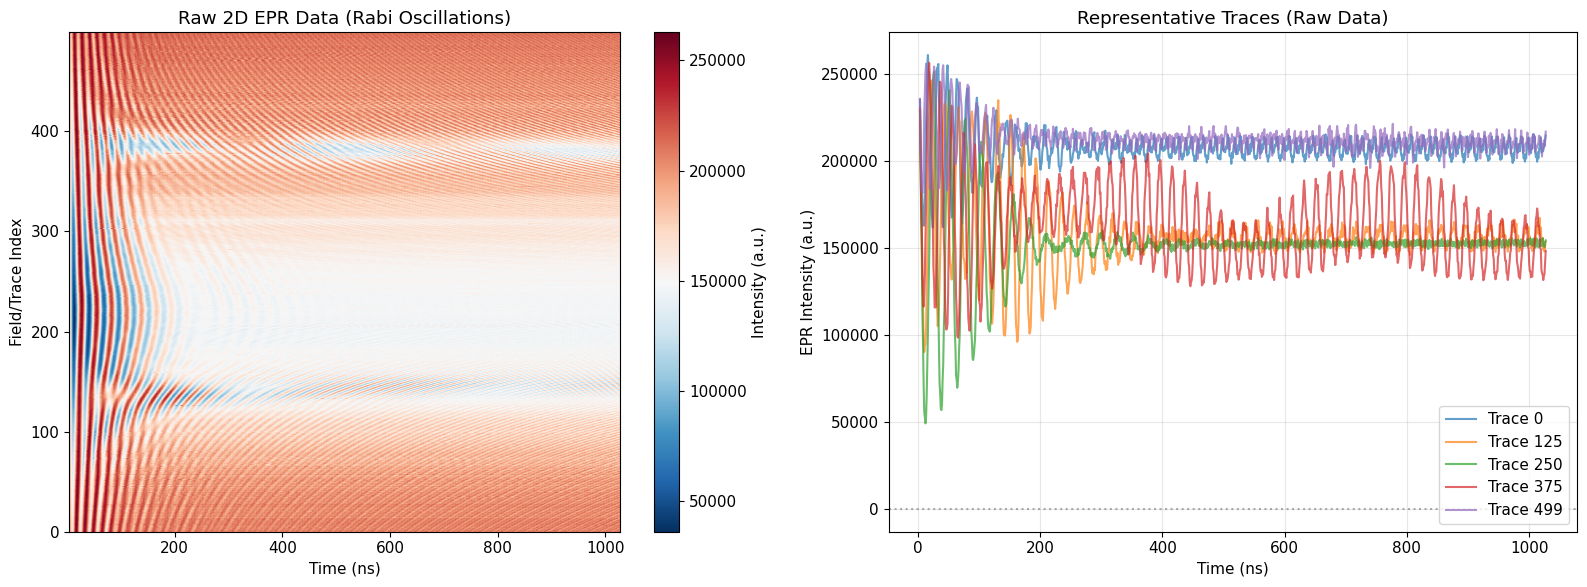


Baseline analysis:
Left edge baseline range: 1.12e+05 to 2.14e+05
Right edge baseline range: 1.43e+05 to 2.11e+05
Baseline drift detected across traces: 3.03e+04


In [12]:
# Visualize raw 2D data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2D color map
if y_2d.ndim == 2:
    im = axes[0].imshow(y_2d, aspect='auto', cmap='RdBu_r',
                        extent=[time_axis[0], time_axis[-1], 
                               field_axis_2d[0], field_axis_2d[-1]],
                        origin='lower')
    axes[0].set_xlabel('Time (ns)')
    axes[0].set_ylabel('Field/Trace Index')
    axes[0].set_title('Raw 2D EPR Data (Rabi Oscillations)')
    plt.colorbar(im, ax=axes[0], label='Intensity (a.u.)')
    
    # Plot a few representative traces
    n_traces = y_2d.shape[0]
    trace_indices = [0, n_traces//4, n_traces//2, 3*n_traces//4, -1]
    
    for idx in trace_indices:
        if idx == -1:
            idx = n_traces - 1
        axes[1].plot(time_axis, y_2d[idx, :], 
                    label=f'Trace {idx}', alpha=0.7)
    
    axes[1].set_xlabel('Time (ns)')
    axes[1].set_ylabel('EPR Intensity (a.u.)')
    axes[1].set_title('Representative Traces (Raw Data)')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    axes[1].axhline(y=0, color='k', linestyle=':', alpha=0.3)
    
else:
    # 1D data case
    axes[0].plot(time_axis, y_2d, 'b-')
    axes[0].set_xlabel('Time (ns)')
    axes[0].set_ylabel('EPR Intensity (a.u.)')
    axes[0].set_title('Raw 1D EPR Data')
    axes[0].grid(True, alpha=0.3)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\nBaseline analysis:")
if y_2d.ndim == 2:
    # Analyze baseline drift in 2D data
    edge_avg = 20  # Average first and last 20 points
    baseline_left = np.mean(y_2d[:, :edge_avg], axis=1)
    baseline_right = np.mean(y_2d[:, -edge_avg:], axis=1)
    
    print(f"Left edge baseline range: {baseline_left.min():.2e} to {baseline_left.max():.2e}")
    print(f"Right edge baseline range: {baseline_right.min():.2e} to {baseline_right.max():.2e}")
    print(f"Baseline drift detected across traces: {np.std(baseline_left):.2e}")
else:
    baseline_edges = np.concatenate([y_2d[:20], y_2d[-20:]])
    print(f"Baseline edges std: {np.std(baseline_edges):.2e}")

### Step 3: Apply 2D Baseline Correction

We will correct the baseline for each trace individually using polynomial fitting.

In [13]:
# Apply baseline correction to 2D data
print("Applying 2D baseline correction...\n")

if y_2d.ndim == 2:
    # Try using the built-in 2D correction function first
    try:
        corrected_2d, baseline_2d = epyr.baseline.baseline_polynomial_2d(
            x_2d, y_2d, params_2d,
            order=2,
            axis=1  # Correct along time axis
        )
        print("2D baseline correction successful using baseline_polynomial_2d()")
        
    except Exception as e:
        print(f"Built-in 2D correction failed: {e}")
        print("Using row-by-row correction instead...\n")
        
        # Alternative: correct each row individually
        corrected_2d = np.zeros_like(y_2d)
        baseline_2d = np.zeros_like(y_2d)
        
        n_traces = y_2d.shape[0]
        for i in range(n_traces):
            try:
                # Extract single trace
                trace = y_2d[i, :]
                
                # Apply 1D baseline correction to this trace
                corrected_trace, baseline_trace = epyr.baseline.baseline_polynomial_1d(
                    time_axis, trace, params_2d,
                    order=2
                )
                
                corrected_2d[i, :] = corrected_trace
                baseline_2d[i, :] = baseline_trace
                
            except Exception as row_error:
                print(f"  Warning: Trace {i} correction failed: {row_error}")
                corrected_2d[i, :] = trace
                baseline_2d[i, :] = 0
        
        print(f"Row-by-row correction complete: {n_traces} traces processed")
    
    # Calculate improvement metrics
    edge_avg = 20
    baseline_std_before = np.std(np.concatenate([
        y_2d[:, :edge_avg].flatten(),
        y_2d[:, -edge_avg:].flatten()
    ]))
    baseline_std_after = np.std(np.concatenate([
        corrected_2d[:, :edge_avg].flatten(),
        corrected_2d[:, -edge_avg:].flatten()
    ]))
    
    improvement_factor = baseline_std_before / baseline_std_after
    
    print(f"\nBaseline correction quality:")
    print(f"  Baseline std before: {baseline_std_before:.2e}")
    print(f"  Baseline std after: {baseline_std_after:.2e}")
    print(f"  Improvement factor: {improvement_factor:.2f}x")
    
else:
    # 1D data case
    corrected_2d, baseline_2d = epyr.baseline.baseline_polynomial_1d(
        time_axis, y_2d, params_2d, order=2
    )
    print("1D baseline correction applied")

Applying 2D baseline correction...

Built-in 2D correction failed: baseline_polynomial_2d() got an unexpected keyword argument 'axis'
Using row-by-row correction instead...

Row-by-row correction complete: 500 traces processed

Baseline correction quality:
  Baseline std before: 4.50e+04
  Baseline std after: 3.79e+04
  Improvement factor: 1.19x


### Step 4: Visualize Corrected 2D Data

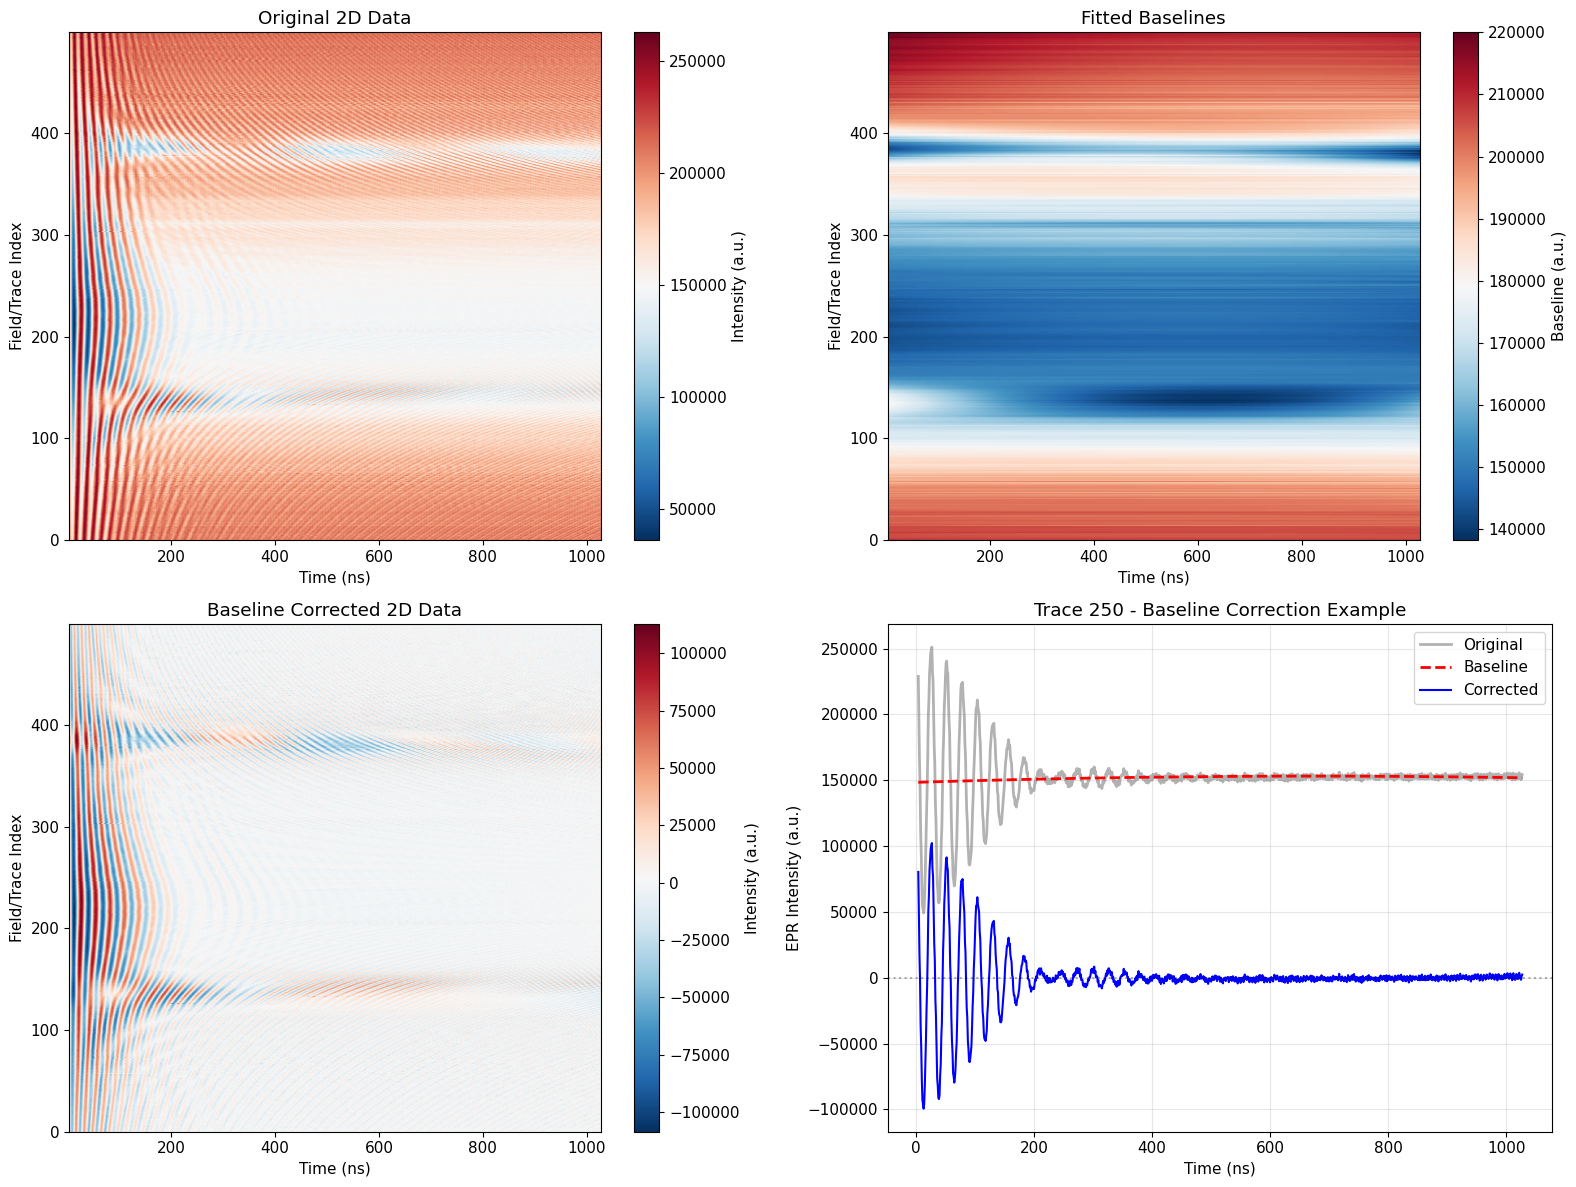


2D baseline correction visualization complete.


In [14]:
# Visualize correction results
if y_2d.ndim == 2:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Original 2D data
    im1 = axes[0, 0].imshow(y_2d, aspect='auto', cmap='RdBu_r',
                            extent=[time_axis[0], time_axis[-1],
                                   field_axis_2d[0], field_axis_2d[-1]],
                            origin='lower')
    axes[0, 0].set_xlabel('Time (ns)')
    axes[0, 0].set_ylabel('Field/Trace Index')
    axes[0, 0].set_title('Original 2D Data')
    plt.colorbar(im1, ax=axes[0, 0], label='Intensity (a.u.)')
    
    # Fitted baselines
    im2 = axes[0, 1].imshow(baseline_2d, aspect='auto', cmap='RdBu_r',
                            extent=[time_axis[0], time_axis[-1],
                                   field_axis_2d[0], field_axis_2d[-1]],
                            origin='lower')
    axes[0, 1].set_xlabel('Time (ns)')
    axes[0, 1].set_ylabel('Field/Trace Index')
    axes[0, 1].set_title('Fitted Baselines')
    plt.colorbar(im2, ax=axes[0, 1], label='Baseline (a.u.)')
    
    # Corrected 2D data
    im3 = axes[1, 0].imshow(corrected_2d, aspect='auto', cmap='RdBu_r',
                            extent=[time_axis[0], time_axis[-1],
                                   field_axis_2d[0], field_axis_2d[-1]],
                            origin='lower')
    axes[1, 0].set_xlabel('Time (ns)')
    axes[1, 0].set_ylabel('Field/Trace Index')
    axes[1, 0].set_title('Baseline Corrected 2D Data')
    plt.colorbar(im3, ax=axes[1, 0], label='Intensity (a.u.)')
    
    # Compare specific traces
    trace_idx = len(field_axis_2d) // 2
    axes[1, 1].plot(time_axis, y_2d[trace_idx, :], 'gray', alpha=0.6,
                   linewidth=2, label='Original')
    axes[1, 1].plot(time_axis, baseline_2d[trace_idx, :], 'r--',
                   linewidth=2, label='Baseline')
    axes[1, 1].plot(time_axis, corrected_2d[trace_idx, :], 'b-',
                   linewidth=1.5, label='Corrected')
    axes[1, 1].set_xlabel('Time (ns)')
    axes[1, 1].set_ylabel('EPR Intensity (a.u.)')
    axes[1, 1].set_title(f'Trace {trace_idx} - Baseline Correction Example')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()
    axes[1, 1].axhline(y=0, color='k', linestyle=':', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    # 1D visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(time_axis, y_2d, 'gray', alpha=0.6, label='Original')
    ax.plot(time_axis, baseline_2d, 'r--', linewidth=2, label='Baseline')
    ax.plot(time_axis, corrected_2d, 'b-', label='Corrected')
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('EPR Intensity (a.u.)')
    ax.set_title('1D Baseline Correction')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

print("\n2D baseline correction visualization complete.")

### Step 5: Analyze Multiple Traces

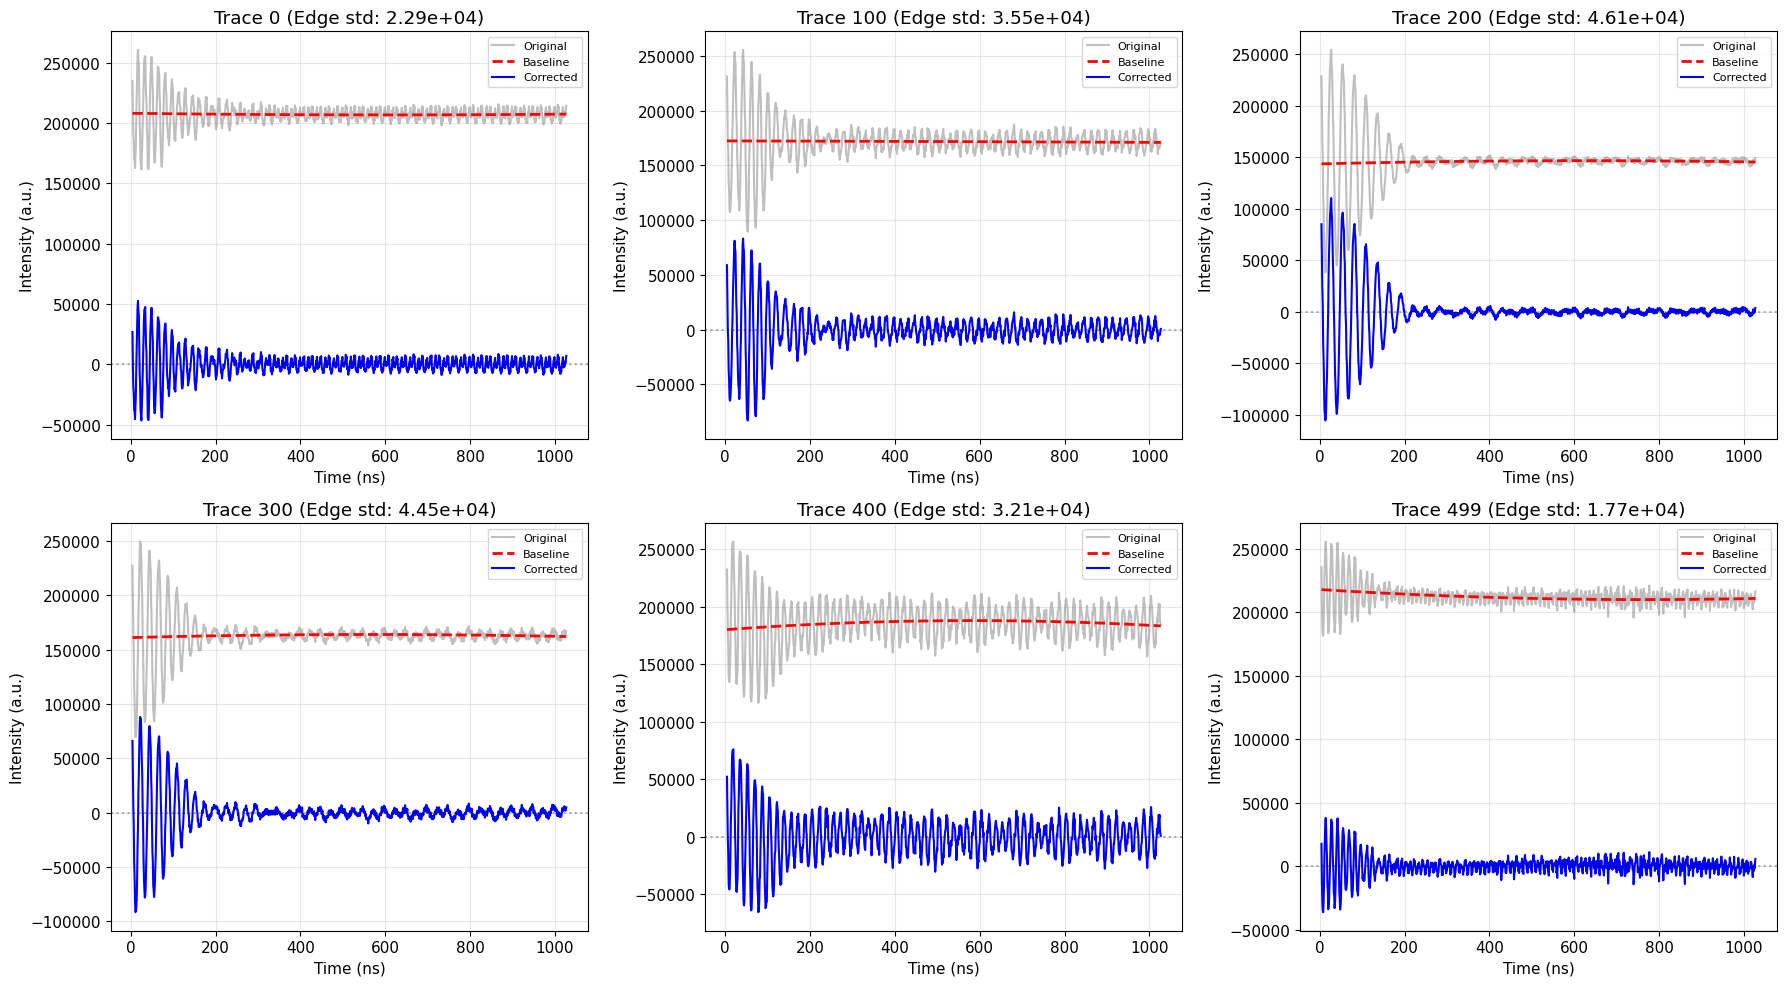


Multi-trace analysis complete.
Analyzed 6 representative traces out of 500 total traces.


In [15]:
# Detailed analysis of correction quality across multiple traces
if y_2d.ndim == 2:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    n_traces = y_2d.shape[0]
    trace_indices = [0, n_traces//5, 2*n_traces//5, 3*n_traces//5, 4*n_traces//5, n_traces-1]
    
    for i, trace_idx in enumerate(trace_indices):
        ax = axes[i]
        
        # Plot original, baseline, and corrected
        ax.plot(time_axis, y_2d[trace_idx, :], 'gray', alpha=0.5,
               linewidth=1.5, label='Original')
        ax.plot(time_axis, baseline_2d[trace_idx, :], 'r--',
               linewidth=2, label='Baseline')
        ax.plot(time_axis, corrected_2d[trace_idx, :], 'b-',
               linewidth=1.5, label='Corrected')
        
        # Calculate quality metrics
        edge_avg = 20
        edge_std = np.std(np.concatenate([
            corrected_2d[trace_idx, :edge_avg],
            corrected_2d[trace_idx, -edge_avg:]
        ]))
        
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel('Intensity (a.u.)')
        ax.set_title(f'Trace {trace_idx} (Edge std: {edge_std:.2e})')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        ax.axhline(y=0, color='k', linestyle=':', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\nMulti-trace analysis complete.")
    print(f"Analyzed {len(trace_indices)} representative traces out of {n_traces} total traces.")

## Summary and Best Practices

### What We've Learned

1. **Baseline Artifacts**: EPR data can suffer from various types of baseline drift due to instrumental and experimental factors

2. **Polynomial Correction**: The polynomial order should match the baseline drift complexity:
   - Order 1 for linear drift
   - Order 2 for quadratic curvature
   - Order 3 for complex baseline shapes

3. **1D Correction**: Works well for CW EPR spectra with smooth baseline variations

4. **2D Correction**: Requires trace-by-trace or slice-by-slice correction for time-domain or multi-dimensional data

### Best Practices

**For 1D Data:**
- Start with visual inspection to identify baseline type
- Use the lowest polynomial order that adequately corrects the drift
- Verify correction by checking edge regions are close to zero
- Compare corrected data with expected signal characteristics

**For 2D Data:**
- Use `baseline_polynomial_2d()` for automatic correction
- If that fails, apply row-by-row correction using `baseline_polynomial_1d()`
- Check multiple traces to ensure consistent correction quality
- Monitor edge statistics to quantify improvement

**Quality Assessment:**
- Calculate baseline standard deviation in edge regions
- Compare with original signal amplitude
- Verify that signal features are preserved
- Check for over-correction or artifacts

### Common Pitfalls to Avoid

- Using too high polynomial order (introduces artifacts)
- Including signal regions in baseline fit
- Not validating correction quality
- Applying 1D correction to 2D data without iteration

### Next Steps

With properly baseline-corrected EPR data, you can proceed to:
- Signal processing and FFT analysis (Tutorial 03)
- Lineshape fitting and analysis (Tutorial 04)
- Quantitative EPR measurements
- Advanced data analysis workflows

## Additional Resources

- EPyR Tools documentation: `help(epyr.baseline)`
- Baseline correction API: `help(epyr.baseline.baseline_polynomial_1d)`
- Interactive baseline selection: `help(epyr.baseline.interactive_select_regions_1d)`

---

**Tutorial complete!** You now understand how to effectively correct baseline artifacts in both 1D and 2D EPR data.

Continue to **Tutorial 03: Signal Processing and Analysis** to learn about FFT-based frequency analysis.